# Análise ampla dos custos de produção do milho 2ª safra — Paraná

Este notebook lê `df_pr_long.csv` (custos de produção CONAB, 1999–2025, cidades do Paraná) e faz uma
análise completa: normalização de categorias, **correção monetária pelo IPCA**, estatística
descritiva, séries temporais, comparação entre cidades, composição de custos, relação
custo × produtividade e métricas de volatilidade.

## Por que corrigir pelo IPCA?

Comparar R$/ha nominal de 1999 com R$/ha nominal de 2025 sem deflacionar embute ~25 anos de
inflação acumulada e mascara se o custo **real** de produção subiu, caiu ou ficou estável. O IPCA
(IBGE) é o deflator padrão usado no Brasil para corrigir valores monetários entre datas — é a base
da própria "Calculadora do Cidadão" do Banco Central e da série de número-índice do IBGE
(tabela 1737/SIDRA).

Os dados oficiais do IPCA usados aqui vêm da série 433 do SGS/Banco Central (variação mensal do
IPCA, mesma base do IBGE). O notebook tenta buscar a série **ao vivo** na API do Banco Central e,
se não houver internet, usa uma cópia local em cache (`ipca_mensal.csv` / `ipca_anual.csv`) para
continuar reprodutível offline.

**Limitação declarada:** os relatórios da CONAB têm um mês de referência específico (ex.
"Março/2020"), mas este dataset só registra o ano. Por isso a correção usa o **índice médio anual**
do IPCA como aproximação, não o mês exato de cada relatório.

In [1]:
import json
import re
import unicodedata
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

pd.set_option("display.width", 140)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

df = pd.read_csv("https://raw.githubusercontent.com/fcoliveira-utfpr/aquacrop_ml/refs/heads/main/df_pr_long.csv")
print(df.shape)
df.head()

(3816, 10)


,cidade,uf,ano,secao,item,custo_rs_ha,custo_rs_60kg,participacao_pct,produtividade_kg_ha,participacao_ct_pct
0,Assis Chateaubriand,PR,2019,I - DESPESAS DE CUSTEIO DA LAVOURA,1 - Operação com animal,0.00,0.00,0.000000,6000.0,NaN
1,Assis Chateaubriand,PR,2019,I - DESPESAS DE CUSTEIO DA LAVOURA,2 - Operação com avião,0.00,0.00,0.000000,6000.0,NaN
2,Assis Chateaubriand,PR,2019,3 - Operação com máquinas próprias:,3.1 - Tratores e Colheitadeiras,104.28,1.03,0.030501,6000.0,NaN
3,Assis Chateaubriand,PR,2019,3 - Operação com máquinas próprias:,3.2 - Conjunto de Irrigação,0.00,0.00,0.000000,6000.0,NaN
4,Assis Chateaubriand,PR,2019,3 - Operação com máquinas próprias:,4 - Aluguel de máquinas,146.74,1.47,0.042921,6000.0,NaN


## 1. Normalização de categorias

Os rótulos de `item` variam de nome entre os 3 layouts que a CONAB usou ao longo dos anos (ex.:
"8 - Sementes" vs "8 - Sementes e mudas"). Duas normalizações:

- **Totais/subtotais** → categoria canônica (Custo Total, Operacional, Variável, Fixo, Despesas de
  Custeio, Outras Despesas, Despesas Financeiras, Depreciações, Outros Custos Fixos, Renda de
  Fatores), identificada por palavra-chave (sem acento, maiúsculas) — robusto aos 3 formatos.
- **Itens individuais relevantes** (fertilizantes, sementes, defensivos, mão de obra, arrendamento,
  transporte, seguro, juros, máquinas/depreciação, administração, terra) → agrupados por
  palavra-chave, para permitir análise de composição sem mapear as ~158 variações uma a uma.

In [2]:
def sem_acento(txt):
    return "".join(c for c in unicodedata.normalize("NFKD", txt) if not unicodedata.combining(c)).upper()


TOTAIS_REGRAS = [
    ("CUSTO TOTAL", "Custo Total (J)"),
    ("CUSTO OPERACIONAL", "Custo Operacional (H)"),
    ("CUSTO VARIAVEL", "Custo Variável (D)"),
    ("CUSTO FIXO", "Custo Fixo (G)"),
    ("CUSTEIO", "Total Despesas de Custeio (A)"),
    ("OUTRAS DESPESAS", "Total Outras Despesas (B)"),
    ("POS-COLHEITA", "Total Outras Despesas (B)"),
    ("FINANCEIRA", "Total Despesas Financeiras (C)"),
    ("DEPRECIA", "Total Depreciações (E)"),
    ("OUTROS CUSTOS FIXOS", "Total Outros Custos Fixos (F)"),
    ("RENDA DE FATORES", "Total Renda de Fatores (I)"),
]


def classificar_total(item):
    t = sem_acento(item)
    if not t.startswith(("TOTAL", "CUSTO")):
        return None
    for chave, categoria in TOTAIS_REGRAS:
        if chave in t:
            return categoria
    return None


ITENS_REGRAS = [
    ("FERTILIZANTE", "Fertilizantes"),
    ("SEMENTE", "Sementes"),
    ("DEFENSIV", "Defensivos/Agrotóxicos"),
    ("AGROTOXIC", "Defensivos/Agrotóxicos"),
    ("MAO DE OBRA", "Mão de obra"),
    ("MAO-DE-OBRA", "Mão de obra"),
    ("ARRENDAMENTO", "Arrendamento"),
    ("TRANSPORTE", "Transporte"),
    ("SEGURO", "Seguro"),
    ("JUROS", "Juros/Financiamento"),
    ("DEPRECIA", "Máquinas/Depreciação"),
    ("MAQUINA", "Máquinas/Depreciação"),
    ("IMPLEMENTO", "Máquinas/Depreciação"),
    ("ADMINISTRA", "Administração"),
    ("TERRA", "Terra"),
]


def classificar_item(item):
    t = sem_acento(item)
    for chave, categoria in ITENS_REGRAS:
        if chave in t:
            return categoria
    return None


df["categoria_total"] = df["item"].apply(classificar_total)
df["categoria_item"] = df["item"].apply(classificar_item)

print("Linhas classificadas como total/subtotal:", df["categoria_total"].notna().sum())
print(df["categoria_total"].value_counts())

Linhas classificadas como total/subtotal: 850
categoria_total
Total Despesas de Custeio (A)     85
Total Outras Despesas (B)         85
Total Despesas Financeiras (C)    85
Custo Variável (D)                85
Total Depreciações (E)            85
Total Outros Custos Fixos (F)     85
Custo Fixo (G)                    85
Custo Operacional (H)             85
Total Renda de Fatores (I)        85
Custo Total (J)                   85
Name: count, dtype: int64


## 2. Correção monetária pelo IPCA

Busca a série 433 do SGS/Banco Central (variação mensal do IPCA). Se a busca ao vivo falhar (sem
internet), usa o cache local `ipca_mensal.csv`. Constrói um número-índice (base dez/1998 = 100),
calcula o índice médio de cada ano, e deflaciona os custos para **R$ de 2025** (último ano completo
disponível no dataset).

In [3]:
URL_BCB = (
    "https://api.bcb.gov.br/dados/serie/bcdata.sgs.433/dados"
    "?formato=json&dataInicial=01/01/1999&dataFinal=31/12/2025"
)
CACHE_MENSAL = Path("ipca_mensal.csv")


def montar_indice_ipca():
    try:
        with urllib.request.urlopen(URL_BCB, timeout=10) as resp:
            dados = json.load(resp)
        ipca = pd.DataFrame(dados)
        ipca["data"] = pd.to_datetime(ipca["data"], format="%d/%m/%Y")
        ipca["valor"] = ipca["valor"].astype(float)
        ipca = ipca.sort_values("data").reset_index(drop=True)
        indice = [100.0]
        for v in ipca["valor"]:
            indice.append(indice[-1] * (1 + v / 100))
        ipca["indice"] = indice[1:]
        ipca["ano"] = ipca["data"].dt.year
        ipca["mes"] = ipca["data"].dt.month
        print("IPCA obtido ao vivo da API do Banco Central (série 433).")
        return ipca[["ano", "mes", "indice"]]
    except Exception as exc:
        print(f"Falha ao buscar IPCA ao vivo ({exc!r}); usando cache local {CACHE_MENSAL}.")
        return pd.read_csv(CACHE_MENSAL)[["ano", "mes", "indice"]]


ipca_mensal = montar_indice_ipca()
ipca_anual = ipca_mensal.groupby("ano")["indice"].mean().rename("indice_medio").reset_index()

ANO_BASE = 2025
indice_base = ipca_anual.loc[ipca_anual["ano"] == ANO_BASE, "indice_medio"].iloc[0]
ipca_anual["fator_deflator"] = indice_base / ipca_anual["indice_medio"]

print(f"Ano-base da correção: {ANO_BASE} (índice médio = {indice_base:.2f})")
ipca_anual.tail(10)

IPCA obtido ao vivo da API do Banco Central (série 433).
Ano-base da correção: 2025 (índice médio = 500.68)


,ano,indice_medio,fator_deflator
17,2016,321.414358,1.557740
18,2017,332.491284,1.505844
19,2018,344.676014,1.452610
20,2019,357.542908,1.400335
21,2020,369.025724,1.356762
22,2021,399.660666,1.252763
23,2022,436.748922,1.146379
24,2023,456.811114,1.096033
25,2024,476.761965,1.050168
26,2025,500.679944,1.000000


In [4]:
df = df.merge(ipca_anual[["ano", "fator_deflator"]], on="ano", how="left")

df["custo_rs_ha_real"] = df["custo_rs_ha"] * df["fator_deflator"]
df["custo_rs_60kg_real"] = df["custo_rs_60kg"] * df["fator_deflator"]

# Sanidade: custo total nominal x real, Londrina, últimos anos
(
    df[(df["cidade"] == "Londrina") & (df["categoria_total"] == "Custo Total (J)")]
    [["ano", "custo_rs_ha", "fator_deflator", "custo_rs_ha_real"]]
    .sort_values("ano")
    .tail(10)
)

,ano,custo_rs_ha,fator_deflator,custo_rs_ha_real
2364,2016,2810.18,1.557740,4377.529277
2419,2017,2870.23,1.505844,4322.118092
2474,2018,3602.93,1.452610,5233.653390
2528,2019,3604.59,1.400335,5047.634495
2574,2020,4445.11,1.356762,6030.954698
2620,2021,4986.62,1.252763,6247.051136
2666,2022,8119.33,1.146379,9307.832216
2712,2023,8542.61,1.096033,9362.980363
2758,2024,7428.42,1.050168,7801.085615
2804,2025,7498.76,1.000000,7498.760000


## 3. Base de análise: Custo Total (R$/ha) real por cidade e ano

A maior parte da análise a seguir usa a linha **"Custo Total (J)"** de cada cidade/ano — é o único
item presente e comparável em todos os anos/formatos.

In [5]:
custo_total = (
    df[df["categoria_total"] == "Custo Total (J)"]
    .sort_values(["cidade", "ano"])
    .reset_index(drop=True)
)
print(f"{len(custo_total)} observações cidade-ano com Custo Total.")
custo_total[["cidade", "ano", "custo_rs_ha", "custo_rs_ha_real", "custo_rs_60kg_real", "produtividade_kg_ha"]].head(10)

85 observações cidade-ano com Custo Total.


,cidade,ano,custo_rs_ha,custo_rs_ha_real,custo_rs_60kg_real,produtividade_kg_ha
0,Assis Chateaubriand,2019,3418.860414,4787.550805,47.821449,6000.0
1,Assis Chateaubriand,2020,3446.300000,4675.807613,46.754006,6000.0
2,Assis Chateaubriand,2021,4034.250000,5053.957600,50.528815,6000.0
3,Assis Chateaubriand,2022,6726.820000,7711.487513,77.114841,6000.0
4,Assis Chateaubriand,2023,7884.310000,8641.462001,86.414543,6000.0
5,Campo Mourão,1999,346.100000,1653.227547,33.054997,3000.0
6,Campo Mourão,2002,615.910000,2372.034499,47.447622,3000.0
7,Campo Mourão,2003,662.860000,2225.396490,44.483757,3000.0
8,Campo Mourão,2004,857.590000,2700.948105,54.013293,3000.0
9,Campo Mourão,2005,892.730000,2630.874397,52.633402,3000.0


## 4. Estatística descritiva (Custo Total real, R$/ha)

In [6]:
resumo = custo_total.groupby("cidade")["custo_rs_ha_real"].agg(
    n="count", media="mean", mediana="median", desvio_padrao="std", minimo="min", maximo="max"
)
resumo["cv_%"] = 100 * resumo["desvio_padrao"] / resumo["media"]
resumo.sort_values("media", ascending=False).round(2)

,n,media,mediana,desvio_padrao,minimo,maximo,cv_%
cidade,,,,,,,
M. Cândido Rondon,3,8363.73,7826.23,1705.71,6991.51,10273.44,20.39
Francisco Beltrão,7,8287.23,9076.40,2970.48,5052.14,12567.30,35.84
Assis Chateaubriand,5,6174.05,5053.96,1862.36,4675.81,8641.46,30.16
Ubiratã,18,5111.41,4564.51,2326.56,2412.68,9863.54,45.52
Londrina,27,4359.03,3280.40,2054.01,2576.19,9362.98,47.12
Campo Mourão,25,4060.98,2764.29,2311.11,1653.23,9377.03,56.91


## 5. Séries temporais e CAGR real

Evolução do custo real por cidade, com **CAGR** (taxa de crescimento anual composta) calculada
entre o primeiro e o último ano disponível de cada cidade.

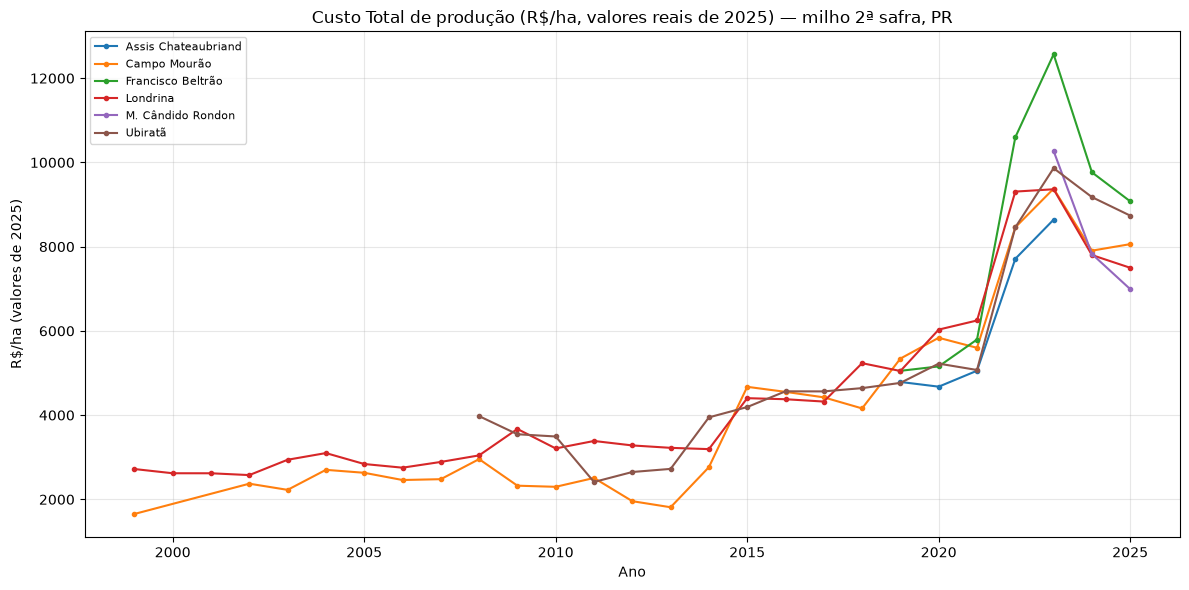

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
for cidade, grupo in custo_total.groupby("cidade"):
    ax.plot(grupo["ano"], grupo["custo_rs_ha_real"], marker="o", markersize=3, label=cidade)
ax.set_title(f"Custo Total de produção (R$/ha, valores reais de {ANO_BASE}) — milho 2ª safra, PR")
ax.set_xlabel("Ano")
ax.set_ylabel(f"R$/ha (valores de {ANO_BASE})")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [8]:
def cagr(grupo):
    grupo = grupo.sort_values("ano")
    ano_i, ano_f = grupo["ano"].iloc[0], grupo["ano"].iloc[-1]
    v_i, v_f = grupo["custo_rs_ha_real"].iloc[0], grupo["custo_rs_ha_real"].iloc[-1]
    n = ano_f - ano_i
    if n <= 0 or v_i <= 0:
        return np.nan
    return 100 * ((v_f / v_i) ** (1 / n) - 1)


cagr_por_cidade = custo_total.groupby("cidade").apply(cagr, include_groups=False).rename("cagr_%_aa")
cagr_por_cidade.sort_values(ascending=False).round(2).to_frame()

,cagr_%_aa
cidade,
Assis Chateaubriand,15.91
Francisco Beltrão,10.26
Campo Mourão,6.28
Ubiratã,4.74
Londrina,3.98
M. Cândido Rondon,-17.51


## 6. Comparação entre cidades (distribuição do custo real)

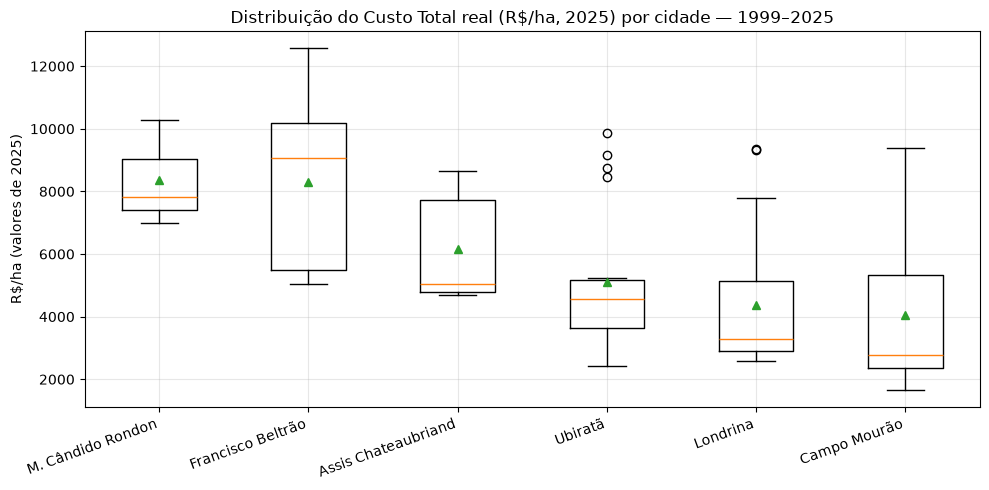

In [9]:
ordem = resumo.sort_values("media", ascending=False).index
dados_box = [custo_total.loc[custo_total["cidade"] == c, "custo_rs_ha_real"].dropna() for c in ordem]

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(dados_box, tick_labels=ordem, showmeans=True)
ax.set_title(f"Distribuição do Custo Total real (R$/ha, {ANO_BASE}) por cidade — 1999–2025")
ax.set_ylabel(f"R$/ha (valores de {ANO_BASE})")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 7. Composição de custos ao longo do tempo

Participação (%) dos grandes grupos de custo (sobre o Custo Total) em cada ano, para a cidade com a
série histórica mais longa (Londrina), usando a coluna já calculada pela CONAB
(`participacao_ct_pct`, quando disponível nas linhas de subtotal).

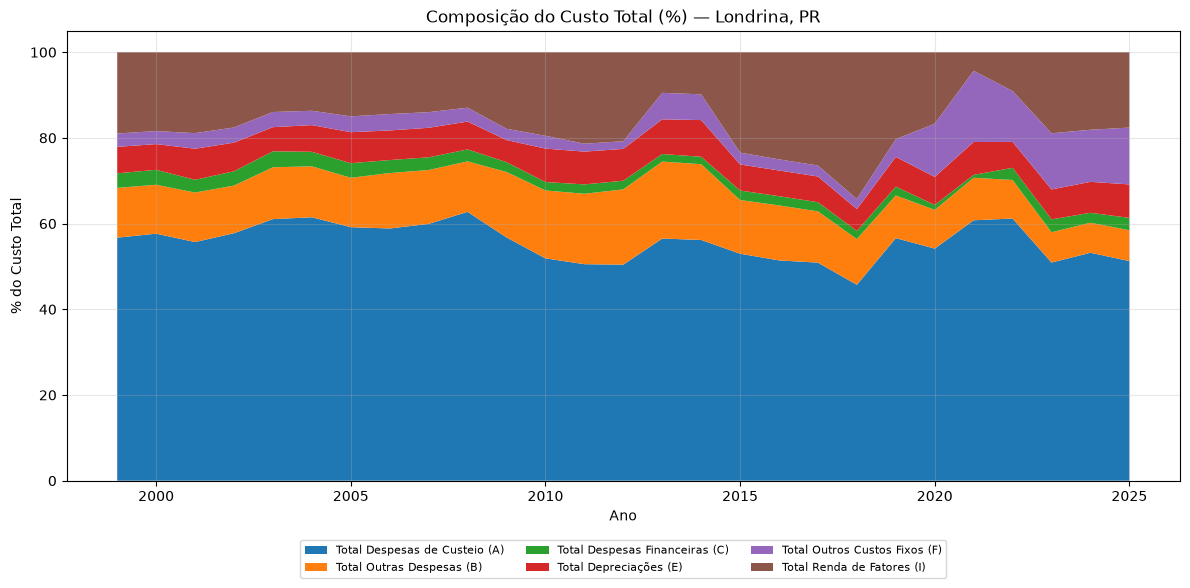

In [10]:
grupos_para_composicao = [
    "Total Despesas de Custeio (A)",
    "Total Outras Despesas (B)",
    "Total Despesas Financeiras (C)",
    "Total Depreciações (E)",
    "Total Outros Custos Fixos (F)",
    "Total Renda de Fatores (I)",
]

composicao = (
    df[(df["cidade"] == "Londrina") & (df["categoria_total"].isin(grupos_para_composicao))]
    .pivot_table(index="ano", columns="categoria_total", values="custo_rs_ha_real", aggfunc="first")
    .reindex(columns=grupos_para_composicao)
)

composicao_pct = composicao.div(composicao.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 6))
ax.stackplot(composicao_pct.index, composicao_pct.T, labels=composicao_pct.columns)
ax.set_title("Composição do Custo Total (%) — Londrina, PR")
ax.set_ylabel("% do Custo Total")
ax.set_xlabel("Ano")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

## 8. Custo por saca (R$/60kg) real — métrica de custo unitário

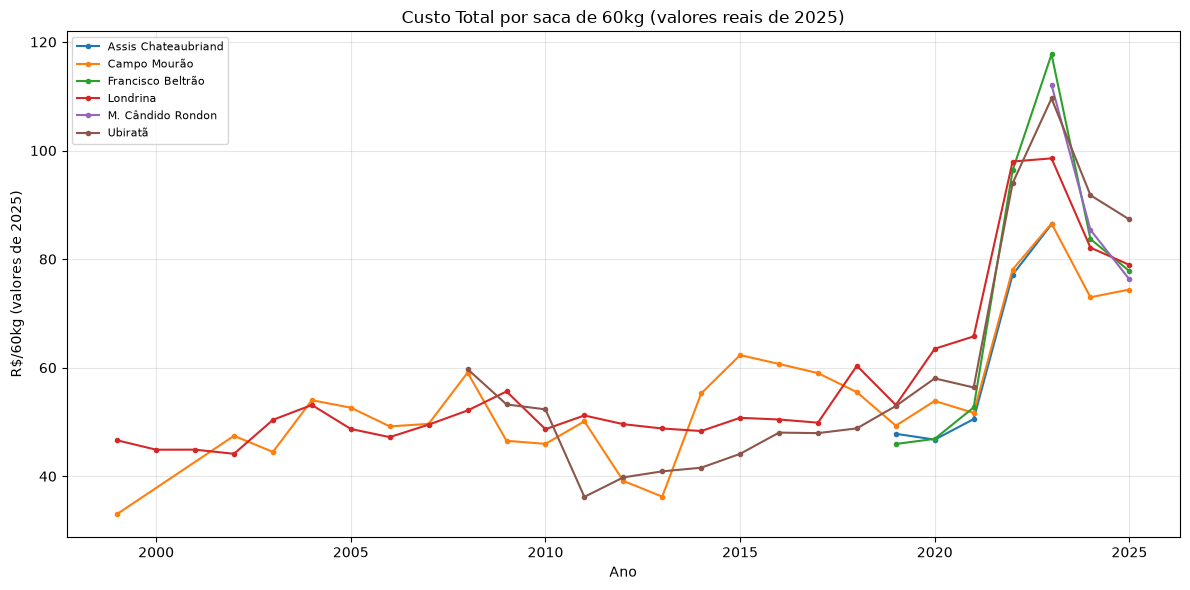

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))
for cidade, grupo in custo_total.groupby("cidade"):
    ax.plot(grupo["ano"], grupo["custo_rs_60kg_real"], marker="o", markersize=3, label=cidade)
ax.set_title(f"Custo Total por saca de 60kg (valores reais de {ANO_BASE})")
ax.set_xlabel("Ano")
ax.set_ylabel(f"R$/60kg (valores de {ANO_BASE})")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 9. Relação custo real × produtividade

Dispersão entre produtividade (kg/ha) e custo real (R$/ha), com correlação de Pearson e Spearman.

Pearson  r = 0.809 (p = 0.0000)
Spearman r = 0.869 (p = 0.0000)


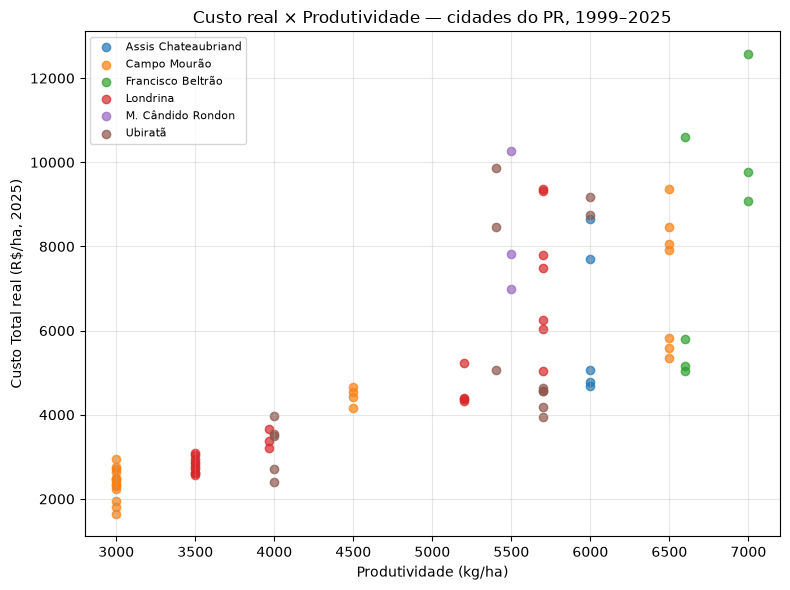

In [12]:
dados_corr = custo_total.dropna(subset=["produtividade_kg_ha", "custo_rs_ha_real"])
pearson_r, pearson_p = stats.pearsonr(dados_corr["produtividade_kg_ha"], dados_corr["custo_rs_ha_real"])
spearman_r, spearman_p = stats.spearmanr(dados_corr["produtividade_kg_ha"], dados_corr["custo_rs_ha_real"])

print(f"Pearson  r = {pearson_r:.3f} (p = {pearson_p:.4f})")
print(f"Spearman r = {spearman_r:.3f} (p = {spearman_p:.4f})")

fig, ax = plt.subplots(figsize=(8, 6))
for cidade, grupo in dados_corr.groupby("cidade"):
    ax.scatter(grupo["produtividade_kg_ha"], grupo["custo_rs_ha_real"], label=cidade, alpha=0.7)
ax.set_xlabel("Produtividade (kg/ha)")
ax.set_ylabel(f"Custo Total real (R$/ha, {ANO_BASE})")
ax.set_title("Custo real × Produtividade — cidades do PR, 1999–2025")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 10. Volatilidade do custo real (variação ano a ano)

Variação percentual anual do custo real e o coeficiente de variação (CV) dessa variação, por
cidade — quanto maior o CV, mais instável é o custo de produção da cidade ao longo do tempo.

In [13]:
custo_total = custo_total.sort_values(["cidade", "ano"])
custo_total["var_pct_aa"] = custo_total.groupby("cidade")["custo_rs_ha_real"].pct_change() * 100

volatilidade = custo_total.groupby("cidade")["var_pct_aa"].agg(
    media_pct_aa="mean", desvio_padrao_pct_aa="std"
)
volatilidade["cv"] = (volatilidade["desvio_padrao_pct_aa"] / volatilidade["media_pct_aa"].abs()).round(2)
volatilidade.sort_values("desvio_padrao_pct_aa", ascending=False).round(2)

,media_pct_aa,desvio_padrao_pct_aa,cv
cidade,,,
Francisco Beltrão,14.43,36.52,2.53
Assis Chateaubriand,17.60,24.10,1.37
Campo Mourão,9.12,24.09,2.64
Ubiratã,6.59,21.64,3.28
Londrina,4.86,14.66,3.01
M. Cândido Rondon,-17.24,9.30,0.54


## 11. Nominal vs. real — quanto do crescimento é só inflação?

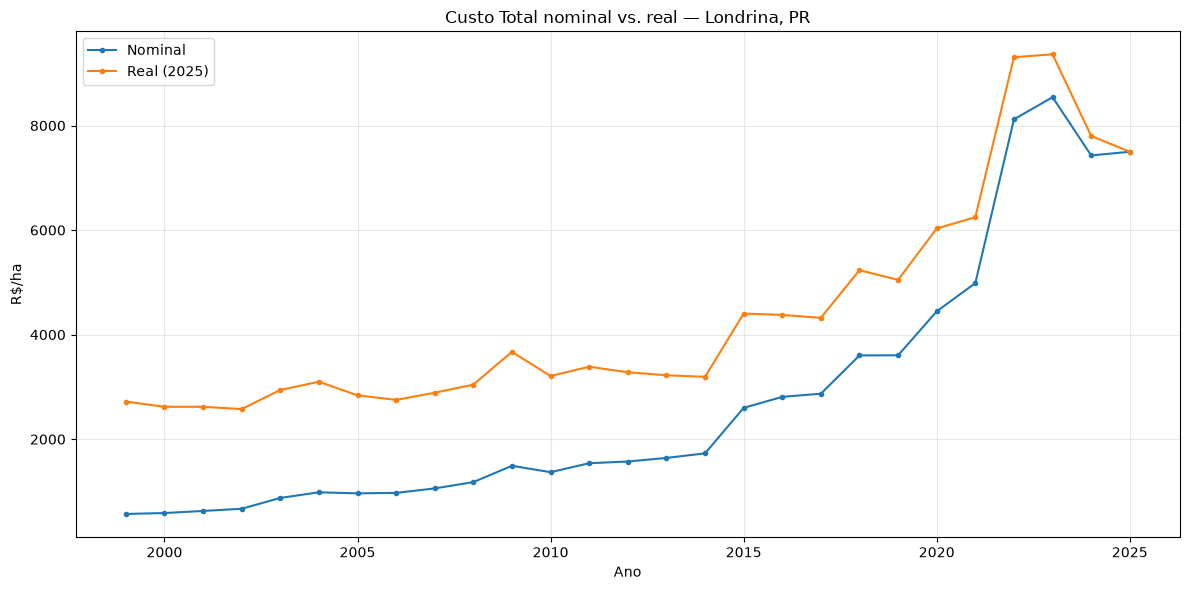

In [14]:
londrina = custo_total[custo_total["cidade"] == "Londrina"].sort_values("ano")

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(londrina["ano"], londrina["custo_rs_ha"], marker="o", markersize=3, label="Nominal")
ax.plot(londrina["ano"], londrina["custo_rs_ha_real"], marker="o", markersize=3, label=f"Real ({ANO_BASE})")
ax.set_title("Custo Total nominal vs. real — Londrina, PR")
ax.set_xlabel("Ano")
ax.set_ylabel("R$/ha")
ax.legend()
plt.tight_layout()
plt.show()

## 12. Cidades de referência de custo para o Oeste do PR (agricultura familiar)

Para usar como referência de custo em municípios do Oeste do Paraná (fora da série CONAB), foram
escolhidas **Assis Chateaubriand**, **Francisco Beltrão** e **M. Cândido Rondon** — não as 3
cidades de maior porte da amostra (Londrina, Campo Mourão, Ubiratã), mas as que são enquadradas em
**agricultura familiar**, perfil mais parecido com o que ocorre no Oeste do PR.

Esta seção verifica se essas 3 cidades realmente têm custo semelhante entre si ao longo da série
histórica — o que sustentaria usá-las como um grupo de referência único (ex. média do grupo) em vez
de tratar cada uma isoladamente.

In [15]:
GRUPO_FAMILIAR = ["Assis Chateaubriand", "Francisco Beltrão", "M. Cândido Rondon"]

custo_total["grupo"] = np.where(
    custo_total["cidade"].isin(GRUPO_FAMILIAR),
    "Agricultura familiar (ref. Oeste)",
    "Demais cidades (maior escala)",
)

resumo_grupo = custo_total.groupby("grupo")["custo_rs_ha_real"].agg(n="count", media="mean", desvio_padrao="std")
resumo_grupo["cv_%"] = 100 * resumo_grupo["desvio_padrao"] / resumo_grupo["media"]
resumo_grupo.round(2)

,n,media,desvio_padrao,cv_%
grupo,,,,
Agricultura familiar (ref. Oeste),15,7598.14,2505.10,32.97
Demais cidades (maior escala),70,4446.05,2225.61,50.06


### Dispersão entre as cidades dentro de cada grupo

Se as 3 cidades de agricultura familiar têm custo parecido *entre si*, a variação das médias das
cidades dentro desse grupo (CV entre cidades) deve ser menor que a variação das médias das cidades
do outro grupo.

In [16]:
media_por_cidade_familiar = (
    custo_total[custo_total["cidade"].isin(GRUPO_FAMILIAR)].groupby("cidade")["custo_rs_ha_real"].mean()
)
media_por_cidade_outras = (
    custo_total[~custo_total["cidade"].isin(GRUPO_FAMILIAR)].groupby("cidade")["custo_rs_ha_real"].mean()
)

cv_entre_cidades_familiar = 100 * media_por_cidade_familiar.std() / media_por_cidade_familiar.mean()
cv_entre_cidades_outras = 100 * media_por_cidade_outras.std() / media_por_cidade_outras.mean()

print("Média de Custo Total real por cidade — agricultura familiar:")
print(media_por_cidade_familiar.round(2).to_string())
print(f"CV entre as médias dessas cidades: {cv_entre_cidades_familiar:.1f}%\n")

print("Média de Custo Total real por cidade — demais cidades:")
print(media_por_cidade_outras.round(2).to_string())
print(f"CV entre as médias dessas cidades: {cv_entre_cidades_outras:.1f}%")

Média de Custo Total real por cidade — agricultura familiar:
cidade
Assis Chateaubriand    6174.05
Francisco Beltrão      8287.23
M. Cândido Rondon      8363.73
CV entre as médias dessas cidades: 16.3%

Média de Custo Total real por cidade — demais cidades:
cidade
Campo Mourão    4060.98
Londrina        4359.03
Ubiratã         5111.41
CV entre as médias dessas cidades: 12.0%


### Teste estatístico (Kruskal-Wallis)

Testa se a distribuição do Custo Total real difere entre as 3 cidades de agricultura familiar.
Kruskal-Wallis (não paramétrico) é mais adequado que ANOVA aqui, dado o número pequeno e desigual de
observações por cidade (Assis Chateaubriand: 2019-2023; Francisco Beltrão: 2019-2025; M. Cândido
Rondon: só 2023-2025 — 3 anos).

In [17]:
grupos_valores = [
    custo_total.loc[custo_total["cidade"] == c, "custo_rs_ha_real"].dropna() for c in GRUPO_FAMILIAR
]
h_stat, p_valor = stats.kruskal(*grupos_valores)
print(f"Kruskal-Wallis entre {GRUPO_FAMILIAR}:")
print(f"H = {h_stat:.3f}, p-valor = {p_valor:.4f}")
if p_valor > 0.05:
    print("Não há evidência estatística de diferença entre as 3 cidades (p > 0,05).")
else:
    print("Há diferença estatisticamente significativa entre as 3 cidades (p <= 0,05).")

Kruskal-Wallis entre ['Assis Chateaubriand', 'Francisco Beltrão', 'M. Cândido Rondon']:
H = 3.381, p-valor = 0.1844
Não há evidência estatística de diferença entre as 3 cidades (p > 0,05).


### Trajetória ao longo do tempo e correlação entre pares

**Atenção:** as 3 cidades têm cobertura de anos bem diferente (M. Cândido Rondon só entra em 2023),
então a correlação par a par pode se apoiar em poucos anos em comum — vale mais como indício do que
como prova.

In [18]:
pivot_familiar = (
    custo_total[custo_total["cidade"].isin(GRUPO_FAMILIAR)]
    .pivot_table(index="ano", columns="cidade", values="custo_rs_ha_real")
)
print("Anos disponíveis por cidade:")
print(pivot_familiar.notna().sum().to_string())
print()
print("Correlação (Pearson) entre as trajetórias de custo real (anos em comum, par a par):")
print(pivot_familiar.corr().round(2))
pivot_familiar

Anos disponíveis por cidade:
cidade
Assis Chateaubriand    5
Francisco Beltrão      7
M. Cândido Rondon      3

Correlação (Pearson) entre as trajetórias de custo real (anos em comum, par a par):
cidade               Assis Chateaubriand  Francisco Beltrão  M. Cândido Rondon
cidade                                                                        
Assis Chateaubriand                  1.0                1.0                NaN
Francisco Beltrão                    1.0                1.0                1.0
M. Cândido Rondon                    NaN                1.0                1.0


cidade,Assis Chateaubriand,Francisco Beltrão,M. Cândido Rondon
ano,,,
2019,4787.550805,5052.143130,NaN
2020,4675.807613,5156.820314,NaN
2021,5053.957600,5794.766247,NaN
2022,7711.487513,10597.566300,NaN
2023,8641.462001,12567.296642,10273.441105
2024,NaN,9765.602541,7826.226626
2025,NaN,9076.400000,6991.510000


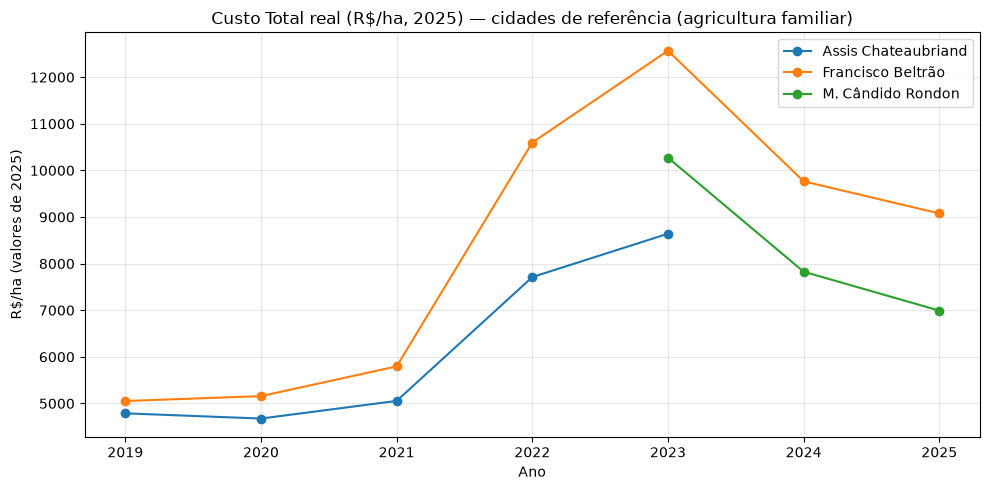

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))
for cidade in GRUPO_FAMILIAR:
    grupo = custo_total[custo_total["cidade"] == cidade].sort_values("ano")
    ax.plot(grupo["ano"], grupo["custo_rs_ha_real"], marker="o", label=cidade)
ax.set_title(f"Custo Total real (R$/ha, {ANO_BASE}) — cidades de referência (agricultura familiar)")
ax.set_xlabel("Ano")
ax.set_ylabel(f"R$/ha (valores de {ANO_BASE})")
ax.legend()
plt.tight_layout()
plt.show()

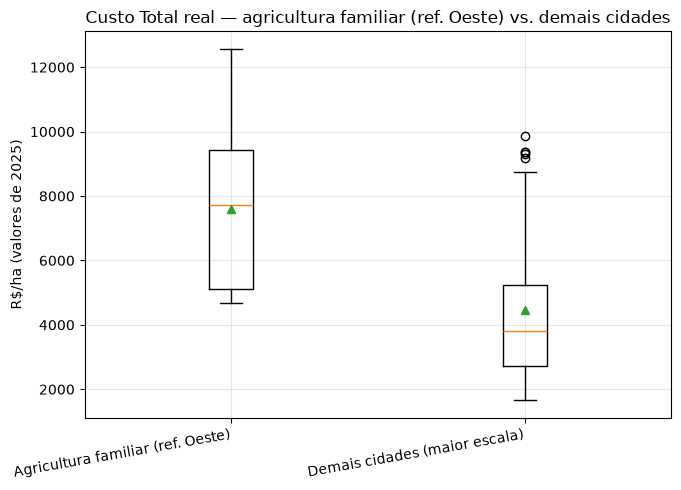

In [20]:
dados_box_grupo = [
    custo_total.loc[custo_total["grupo"] == g, "custo_rs_ha_real"].dropna()
    for g in custo_total["grupo"].unique()
]
fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot(dados_box_grupo, tick_labels=custo_total["grupo"].unique(), showmeans=True)
ax.set_title("Custo Total real — agricultura familiar (ref. Oeste) vs. demais cidades")
ax.set_ylabel(f"R$/ha (valores de {ANO_BASE})")
plt.xticks(rotation=10, ha="right")
plt.tight_layout()
plt.show()

### Composição do custo (estrutura, não só o nível)

Cidades podem ter o mesmo Custo Total e estruturas de custo bem diferentes (ex. uma mais intensiva
em mão de obra, outra em insumos). Aqui comparamos a participação média (%) de cada grande grupo de
custo no Custo Total, por cidade — se as barras forem parecidas, o "perfil" de custo é semelhante,
não só o total.

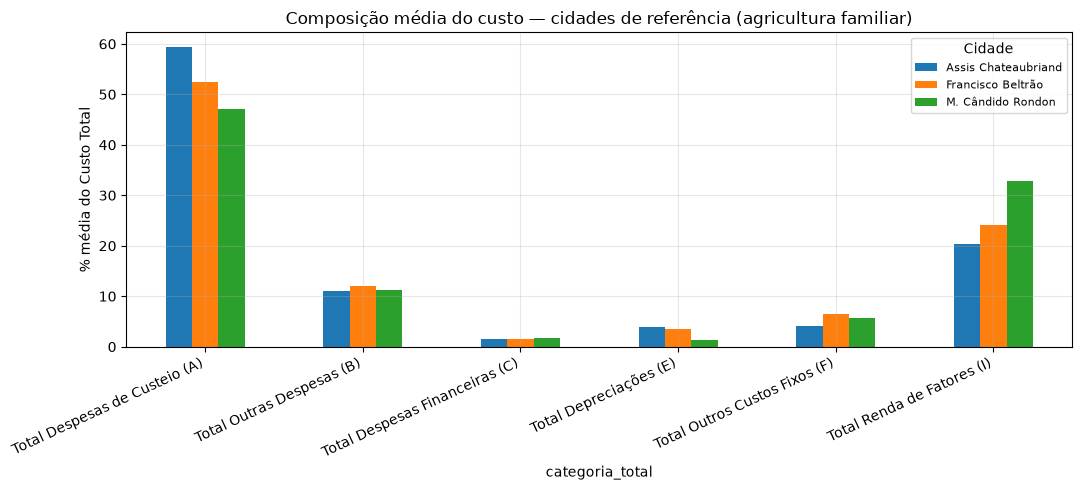

categoria_total,Total Despesas de Custeio (A),Total Outras Despesas (B),Total Despesas Financeiras (C),Total Depreciações (E),Total Outros Custos Fixos (F),Total Renda de Fatores (I)
cidade,,,,,,
Assis Chateaubriand,59.3,11.0,1.4,3.9,4.0,20.4
Francisco Beltrão,52.5,12.0,1.5,3.5,6.5,24.0
M. Cândido Rondon,47.1,11.2,1.8,1.4,5.8,32.8


In [21]:
composicao_familiar = (
    df[df["cidade"].isin(GRUPO_FAMILIAR) & df["categoria_total"].isin(grupos_para_composicao)]
    .pivot_table(index=["cidade", "ano"], columns="categoria_total", values="custo_rs_ha_real", aggfunc="first")
    .reindex(columns=grupos_para_composicao)
)
composicao_pct_familiar = composicao_familiar.div(composicao_familiar.sum(axis=1), axis=0) * 100
media_composicao_por_cidade = composicao_pct_familiar.groupby("cidade").mean()

fig, ax = plt.subplots(figsize=(11, 5))
media_composicao_por_cidade.T.plot(kind="bar", ax=ax)
ax.set_ylabel("% média do Custo Total")
ax.set_title("Composição média do custo — cidades de referência (agricultura familiar)")
ax.legend(title="Cidade", fontsize=8)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

media_composicao_por_cidade.round(1)

### Custo de referência do Oeste (média do grupo)

Série de custo real (R$/ha, valores de 2025), por ano, a partir da **média das cidades disponíveis
no grupo naquele ano** — para usar como referência de custo nos municípios do Oeste do PR na próxima
etapa (classificação de risco econômico com o modelo de produtividade).

In [22]:
custo_referencia_oeste = (
    custo_total[custo_total["cidade"].isin(GRUPO_FAMILIAR)]
    .groupby("ano")["custo_rs_ha_real"]
    .agg(custo_rs_ha_ref_media="mean", n_cidades="count")
    .reset_index()
)
custo_referencia_oeste.to_csv("custo_referencia_oeste_pr.csv", index=False, encoding="utf-8-sig")
print("Arquivo gerado: custo_referencia_oeste_pr.csv")
custo_referencia_oeste

Arquivo gerado: custo_referencia_oeste_pr.csv


,ano,custo_rs_ha_ref_media,n_cidades
0,2019,4919.846968,2
1,2020,4916.313963,2
2,2021,5424.361924,2
3,2022,9154.526906,2
4,2023,10494.066582,3
5,2024,8795.914583,2
6,2025,8033.955000,2


### Interpretação

- **Kruskal-Wallis não rejeitou igualdade** entre as 3 cidades (p = 0,18) — não há evidência
  estatística de que os níveis de custo sejam diferentes, o que sustenta usá-las como grupo.
  Mas ausência de evidência de diferença **não é prova de igualdade**, ainda mais com amostras de
  só 3 a 7 anos por cidade — é uma leitura favorável, não uma confirmação forte.
- **A dispersão entre as médias das 3 cidades (CV = 16,3%) não ficou menor** que a do outro grupo
  de comparação (Londrina/Campo Mourão/Ubiratã, CV = 12,0%). Ou seja, o critério de seleção
  (agricultura familiar) não tornou o nível de custo mais homogêneo entre si do que seria por acaso
  — o principal argumento a favor do grupo continua sendo o critério agronômico (perfil de
  produção), não uma homogeneidade estatística superior.
- **A correlação par a par (r ≈ 1,0 em todos os pares) não é informativa** — é um artefato de ter
  só 1-2 anos em comum entre a maioria dos pares (correlação com 2 pontos é sempre ±1). M. Cândido
  Rondon em particular só tem 2023-2025, o que limita bastante a comparação com essa cidade.
- **A composição do custo tem alguma variação** entre as 3 (ex. "Despesas de Custeio" vai de 47,1%
  em M. Cândido Rondon a 59,3% em Assis Chateaubriand), mas os mesmos grandes grupos dominam a
  estrutura em todas — qualitativamente parecidas, não idênticas.

**Conclusão prática**: usar a média das 3 cidades como referência de custo para o Oeste do PR é
uma escolha razoável dado o critério agronômico (agricultura familiar) e a ausência de diferença
estatística significativa — mas a amostra é pequena, então vale carregar essa incerteza para a
próxima etapa (ex. usar a dispersão entre as 3 cidades como parte da faixa de risco/incerteza do
custo na classificação de risco econômico, em vez de tratar `custo_referencia_oeste_pr.csv` como um
valor exato).

## 13. Exportação

In [23]:
df.to_csv("df_pr_long_deflacionado.csv", index=False, encoding="utf-8-sig")
custo_total.to_csv("custo_total_pr_deflacionado.csv", index=False, encoding="utf-8-sig")
print("Arquivos gerados: df_pr_long_deflacionado.csv, custo_total_pr_deflacionado.csv")

Arquivos gerados: df_pr_long_deflacionado.csv, custo_total_pr_deflacionado.csv
